<a href="https://colab.research.google.com/github/JenniEun/Alzheimer-MRI-disease/blob/main/Alzheimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparing to load the Kaggle dataset

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jenniferandrew","key":"29b47e02a552748779c4b871b3039ac8"}'}

Set Up kaggle API

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory


In [4]:
!ls ~/.kaggle

kaggle.json


In [5]:
!pip install kaggle

Download the dataset

In [6]:
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100% 380M/380M [00:05<00:00, 74.3MB/s]



UnZip the dataset directory

In [7]:
import zipfile

with zipfile.ZipFile('augmented-alzheimer-mri-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/alzheimer_data')

In [9]:
import os

os.listdir('/content/alzheimer_data')

['OriginalDataset', 'AugmentedAlzheimerDataset']

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/alzheimer_data/AugmentedAlzheimerDataset"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 33984 images belonging to 4 classes.


In [10]:
import os
import random
import matplotlib.pyplot as plt
import cv2

In [11]:
base_path = "/content/alzheimer_data/AugmentedAlzheimerDataset"
classes = os.listdir(base_path)

print("Classes:", classes)

Classes: ['VeryMildDemented', 'MildDemented', 'NonDemented', 'ModerateDemented']


Visualizing the dataset


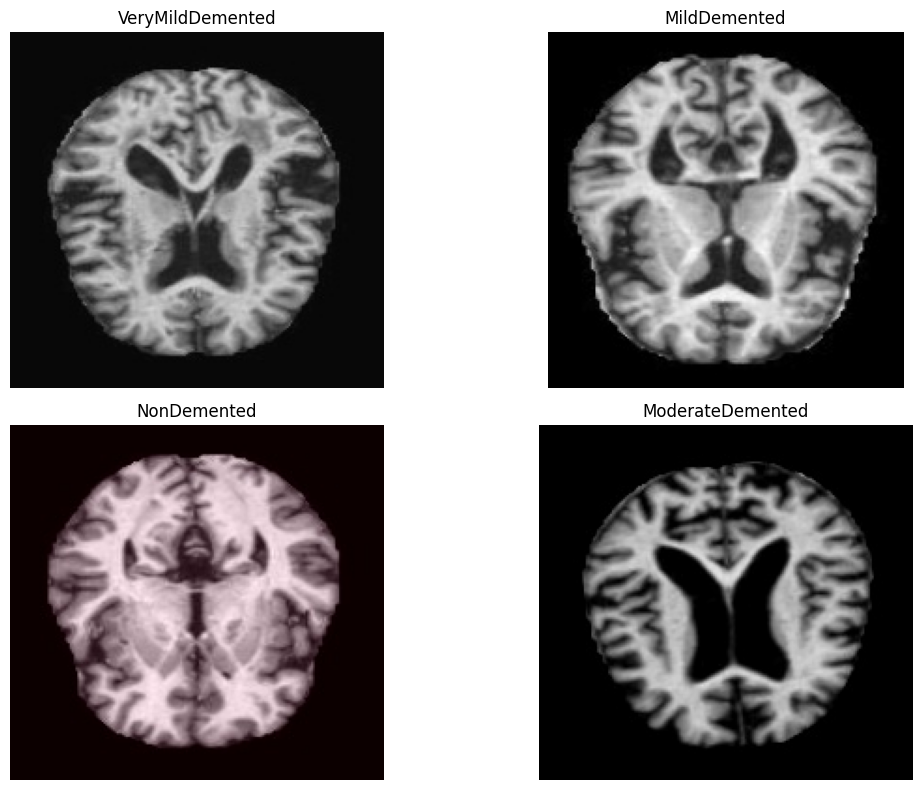

In [12]:
plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

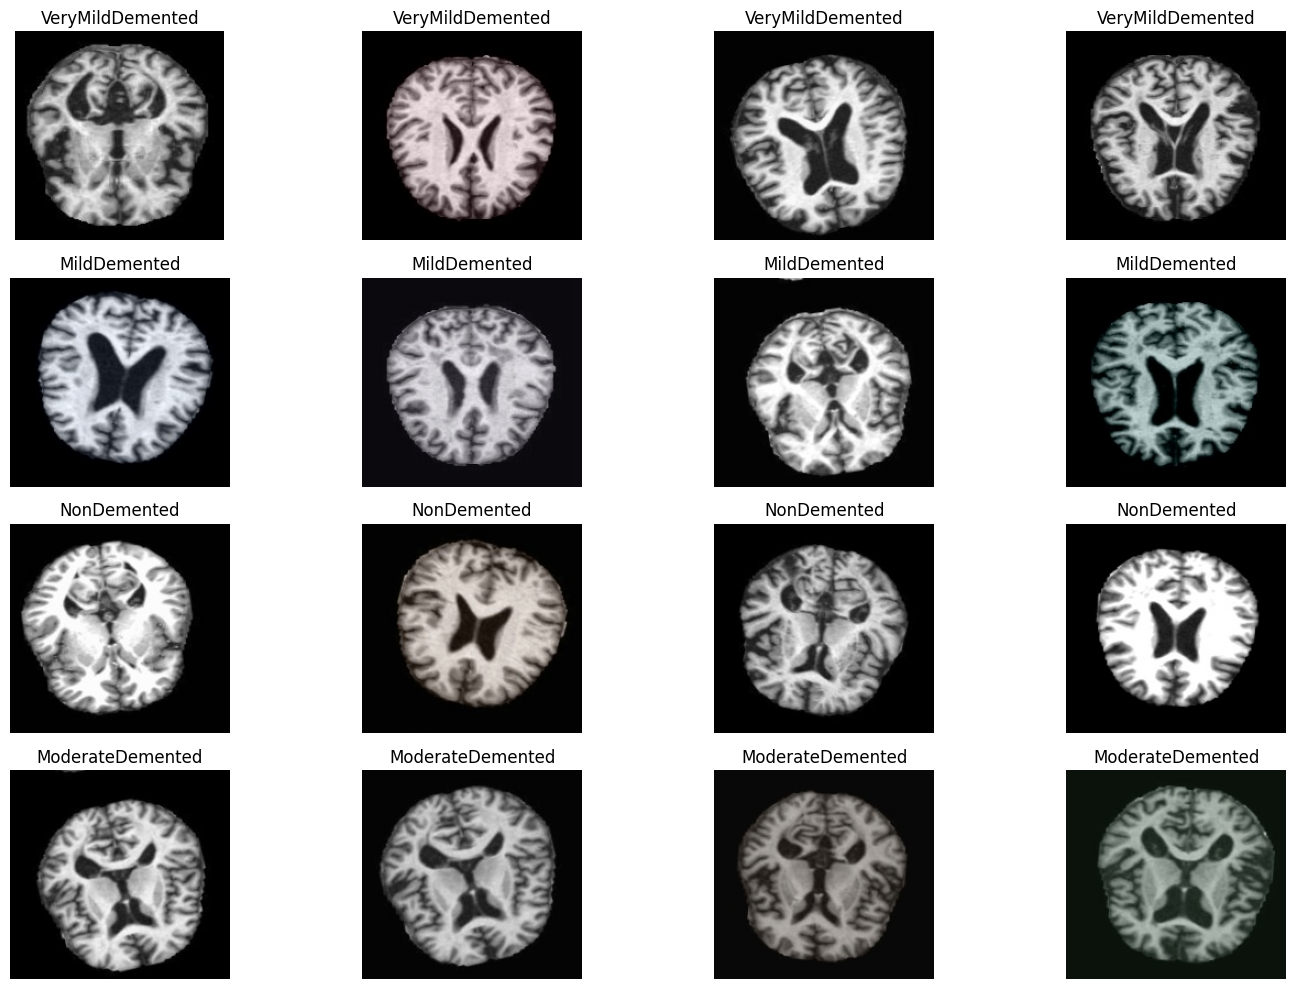

In [13]:
plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)

    images = random.sample(os.listdir(class_path), 4)

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 4, i*4 + j + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

Class Distribution


In [14]:
import pandas as pd

data = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)
    count = len(os.listdir(class_path))
    data.append((class_name, count))

df = pd.DataFrame(data, columns=["Class", "Count"])
print(df)

              Class  Count
0  VeryMildDemented   8960
1      MildDemented   8960
2       NonDemented   9600
3  ModerateDemented   6464


In [15]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50

In [16]:
# For training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,  # 15% of data for validation
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 28887 images belonging to 4 classes.
Found 5097 images belonging to 4 classes.


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [18]:
checkpoint = ModelCheckpoint(
    "best_model.h5",           # file name
    monitor="val_accuracy",   # monitor validation accuracy
    save_best_only=True,      # save only best model
    mode="max",
    verbose=1
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

In [20]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,              # reduce LR by 70%
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [21]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,596 (84.86 MB)

 Trainable params: 22,246,148 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.3203 - loss: 1.6071
Epoch 1: val_accuracy improved from None to 0.39180, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
903/903 ━━━━━━━━━━━━━━━━━━━━ 521s 563ms/step - accuracy: 0.3413 - loss: 1.3732 - val_accuracy: 0.3918 - val_loss: 1.2838 - learning_rate: 1.0000e-04
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.3834 - loss: 1.2578
Epoch 2: val_accuracy improved from 0.39180 to 0.47655, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
903/903 ━━━━━━━━━━━━━━━━━━━━ 506s 560ms/step - accuracy: 0.3938 - loss: 1.2310 - val_accuracy: 0.4766 - val_loss: 1.1022 - learning_rate: 1.0000e-04
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.4321 - loss: 1.1622
Epoch 3: val_accuracy did not improve from 0.47655
903/903 ━━━━━━━━━━━━━━━━━━━━ 498s 551ms/step - accuracy: 0.4485 - loss: 1.1415 - val_accuracy: 0.4552 - val_loss: 1.1562 - learning_rate: 1.0000e-04
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.4791 - loss: 1.0806
Epoch 4: val_accuracy improved from 0.47655 to 0.54640, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
903/903 ━━━━━━━━━━━━━━━━━━━━ 504s 558ms/step - accuracy: 0.4926 - loss: 1.0633 - val_accuracy: 0.5464 - val_loss: 0.9677 - learning_rate: 1.0000e-04
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.5250 - loss: 1.0089
Epoch 5: val_accuracy did not improve from 0.54640
903/903 ━━━━━━━━━━━━━━━━━━━━ 479s 530ms/step - accuracy: 0.5286 - loss: 0.9962 - val_accuracy: 0.5136 - val_loss: 1.0788 - learning_rate: 1.0000e-04
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5491 - loss: 0.9593
Epoch 6: val_accuracy improved from 0.54640 to 0.61212, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
903/903 ━━━━━━━━━━━━━━━━━━━━ 474s 524ms/step - accuracy: 0.5513 - loss: 0.9502 - val_accuracy: 0.6121 - val_loss: 0.8349 - learning_rate: 1.0000e-04
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.5604 - loss: 0.9228
Epoch 7: val_accuracy did not improve from 0.61212
903/903 ━━━━━━━━━━━━━━━━━━━━ 473s 524ms/step - accuracy: 0.5627 - loss: 0.9192 - val_accuracy: 0.3871 - val_loss: 1.4782 - learning_rate: 1.0000e-04
Epoch 8/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.5723 - loss: 0.8980
Epoch 8: val_accuracy did not improve from 0.61212
903/903 ━━━━━━━━━━━━━━━━━━━━ 487s 539ms/step - accuracy: 0.5724 - loss: 0.8913 - val_accuracy: 0.5801 - val_loss: 0.8761 - learning_rate: 1.0000e-04
Epoch 9/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5859 - loss: 0.8722
Epoch 9: val_accuracy improved from 0.61212 to 0.66117, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
903/903 ━━━━━━━━━━━━━━━━━━━━ 501s 555ms/step - accuracy: 0.5918 - loss: 0.8626 - val_accuracy: 0.6612 - val_loss: 0.7596 - learning_rate: 1.0000e-04
Epoch 10/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.5889 - loss: 0.8518
Epoch 10: val_accuracy did not improve from 0.66117
903/903 ━━━━━━━━━━━━━━━━━━━━ 517s 573ms/step - accuracy: 0.5959 - loss: 0.8447 - val_accuracy: 0.5595 - val_loss: 0.9549 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.


In [24]:
test_dir = "/content/alzheimer_data/OriginalDataset"

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Evaluate
test_loss, test_acc = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Found 6400 images belonging to 4 classes.
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5903 - loss: 0.7934
Test Accuracy: 59.03%


In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

train_dir = "/content/alzheimer_data/AugmentedAlzheimerDataset"
classes = os.listdir(train_dir)

img_size = (224, 224)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 28887 images belonging to 4 classes.
Found 5097 images belonging to 4 classes.


In [26]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_base.trainable = False

vgg_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

vgg_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 270s 275ms/step - accuracy: 0.3548 - loss: 1.3356 - val_accuracy: 0.4157 - val_loss: 1.2330
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 224s 248ms/step - accuracy: 0.4985 - loss: 1.1788 - val_accuracy: 0.5776 - val_loss: 1.0946
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 224s 248ms/step - accuracy: 0.5608 - loss: 1.0655 - val_accuracy: 0.6121 - val_loss: 0.9854
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 226s 250ms/step - accuracy: 0.5966 - loss: 0.9741 - val_accuracy: 0.6423 - val_loss: 0.9062
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 225s 249ms/step - accuracy: 0.6178 - loss: 0.9088 - val_accuracy: 0.6516 - val_loss: 0.8504
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 226s 250ms/step - accuracy: 0.6328 - loss: 0.8615 - val_accuracy: 0.6569 - val_loss: 0.8161
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 225s 249ms/step - accuracy: 0.6449 - loss: 0.8257 - val_accuracy: 0.6688 - val_loss: 0.7810
Epoch 8/10
903/903 ━━━━━━

In [27]:
mob_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
mob_base.trainable = False

mob_model = Sequential([
    mob_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

mob_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mob = mob_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 120s 106ms/step - accuracy: 0.5239 - loss: 1.0713 - val_accuracy: 0.6314 - val_loss: 0.8567
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 62s 68ms/step - accuracy: 0.6316 - loss: 0.8441 - val_accuracy: 0.6484 - val_loss: 0.7767
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.6663 - loss: 0.7629 - val_accuracy: 0.6820 - val_loss: 0.7102
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.6872 - loss: 0.7167 - val_accuracy: 0.7243 - val_loss: 0.6618
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 56s 62ms/step - accuracy: 0.7115 - loss: 0.6746 - val_accuracy: 0.7361 - val_loss: 0.6318
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.7250 - loss: 0.6434 - val_accuracy: 0.7359 - val_loss: 0.6135
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 55s 61ms/step - accuracy: 0.7393 - loss: 0.6138 - val_accuracy: 0.7473 - val_loss: 0.5925
Epoch 8/10
903/903 ━━━━━━━━━━━━━━━━━━━━

In [29]:
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
eff_base.trainable = False

eff_model = Sequential([
    eff_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

eff_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff = eff_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 132s 110ms/step - accuracy: 0.2750 - loss: 1.3822 - val_accuracy: 0.2825 - val_loss: 1.3763
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.2769 - loss: 1.3785 - val_accuracy: 0.2825 - val_loss: 1.3759
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.2775 - loss: 1.3770 - val_accuracy: 0.2825 - val_loss: 1.3758
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.2766 - loss: 1.3775 - val_accuracy: 0.2825 - val_loss: 1.3760
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.2806 - loss: 1.3771 - val_accuracy: 0.2825 - val_loss: 1.3759
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.2776 - loss: 1.3772 - val_accuracy: 0.2825 - val_loss: 1.3762
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.2821 - loss: 1.3774 - val_accuracy: 0.2825 - val_loss: 1.3759
Epoch 8/10
903/903 ━━━━━━━━━━━━━━━━━━

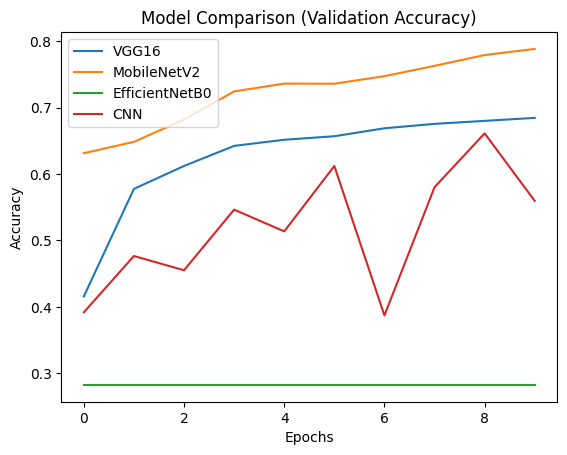

In [31]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['val_accuracy'], label='VGG16')
plt.plot(history_mob.history['val_accuracy'], label='MobileNetV2')
plt.plot(history_eff.history['val_accuracy'], label='EfficientNetB0')
plt.plot(history.history['val_accuracy'], label='CNN')
plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step


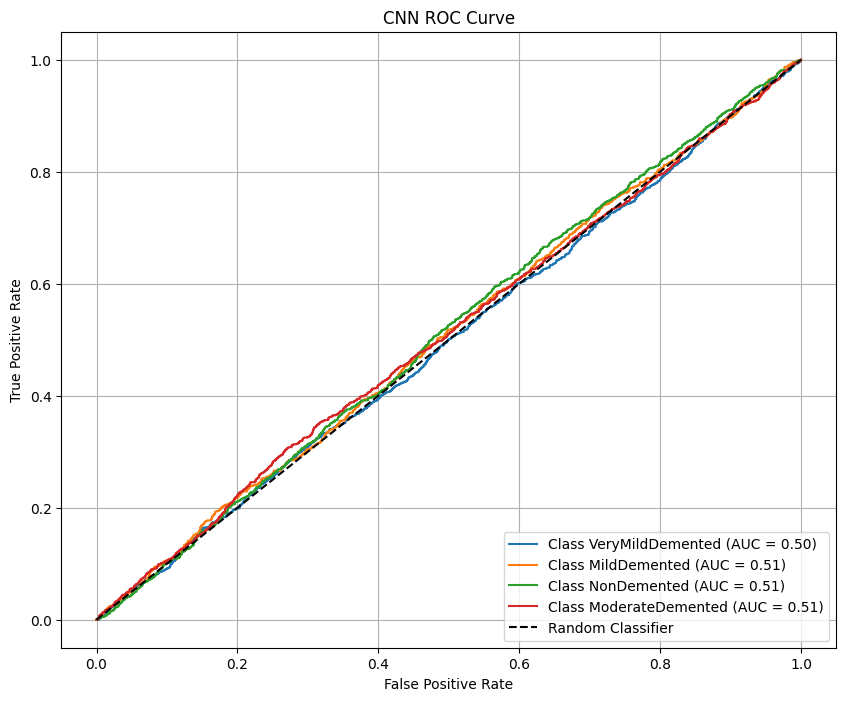

160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step


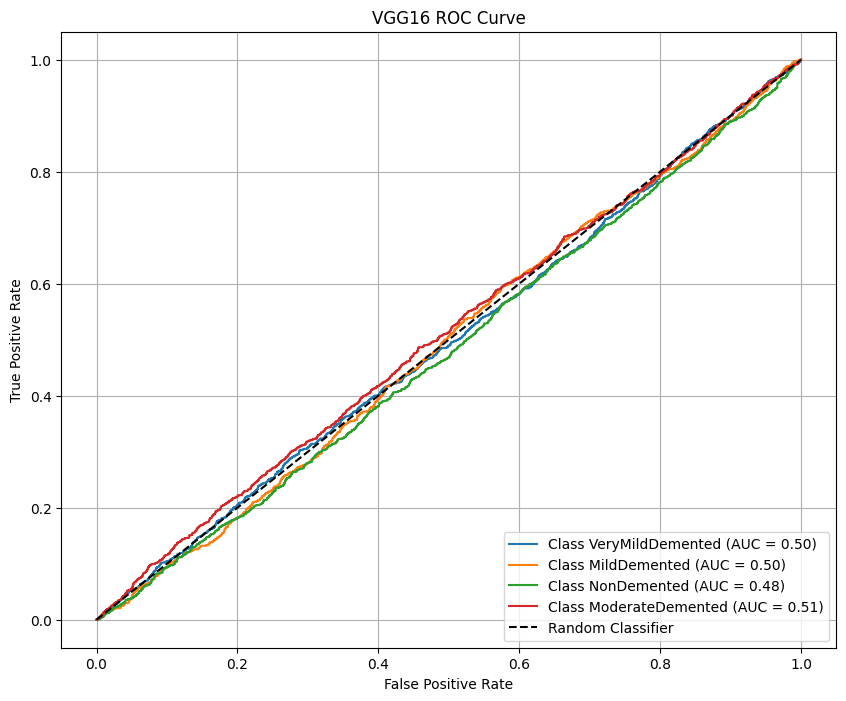

160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step


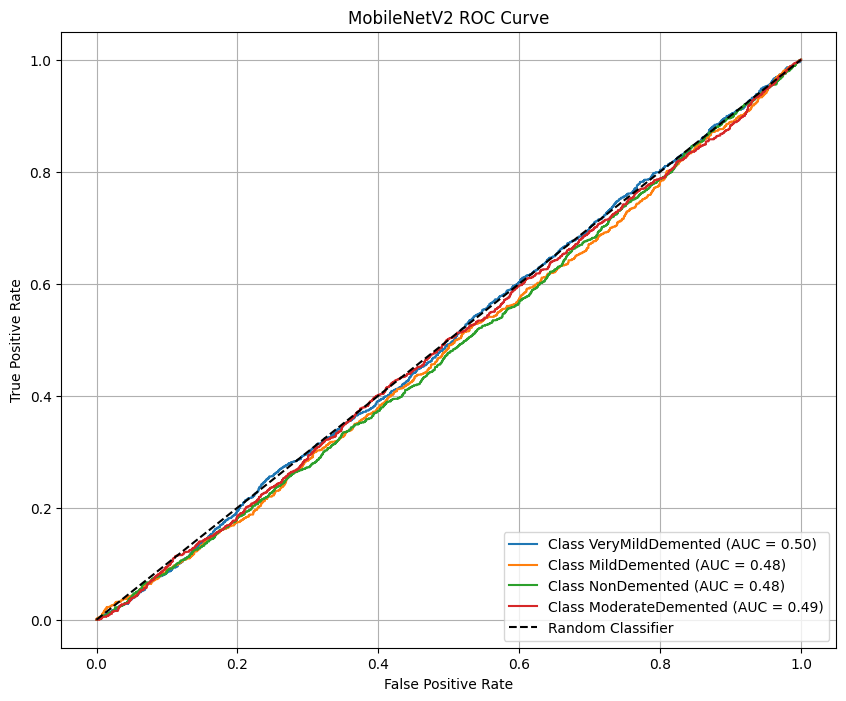

160/160 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step


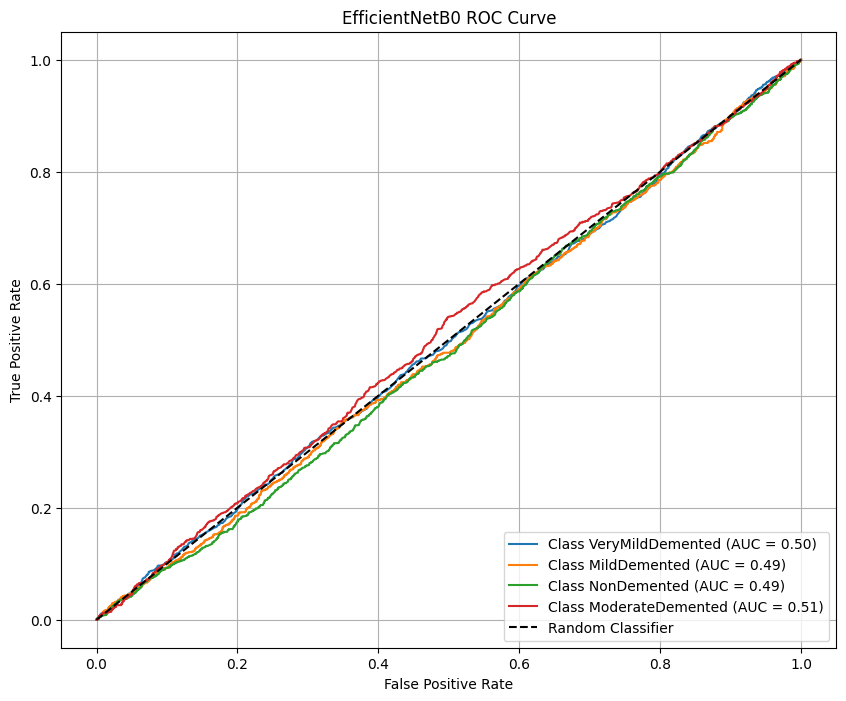

In [33]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define the models dictionary
models = {
    'CNN': cnn_model,
    'VGG16': vgg_model,
    'MobileNetV2': mob_model,
    'EfficientNetB0': eff_model
}

# Define the class_names variable
# From kernel state, class_names is: ['VeryMildDemented', 'MildDemented', 'NonDemented', 'ModerateDemented']
class_names = ['VeryMildDemented', 'MildDemented', 'NonDemented', 'ModerateDemented']

# Define the plot_roc function
def plot_roc(model, data_generator, class_labels, title):
    y_true = data_generator.classes
    y_pred_proba = model.predict(data_generator)

    # Get the number of classes from data_generator's class_indices or actual predictions
    n_classes = len(class_labels)

    # Convert y_true to one-hot encoding if it's not already
    y_true_one_hot = np.zeros((len(y_true), n_classes))
    y_true_one_hot[np.arange(len(y_true)), y_true] = 1

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Original loop from the cell
for name, model in models.items():
    # val_gen is already defined in the notebook
    plot_roc(model, val_gen, class_names, f"{name} ROC Curve")

In [56]:
import cv2

def gradcam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # Use model.inputs (plural) for functional API models
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array]) # Wrap img_array in a list
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap.numpy()

In [39]:
def show_gradcam(model, generator):
    img, label = next(generator)
    img = img[0]

    heatmap = gradcam(model, img[np.newaxis, ...], layer_name="efficientnetb0")

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title("Grad-CAM Visualization")
    plt.axis('off')
    plt.show()

In [41]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

eff_model = Model(inputs, outputs)

eff_model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = eff_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 118s 95ms/step - accuracy: 0.2764 - loss: 1.3826 - val_accuracy: 0.2825 - val_loss: 1.3760
Epoch 2/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 61s 67ms/step - accuracy: 0.2745 - loss: 1.3778 - val_accuracy: 0.2825 - val_loss: 1.3763
Epoch 3/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 57s 64ms/step - accuracy: 0.2752 - loss: 1.3778 - val_accuracy: 0.2825 - val_loss: 1.3757
Epoch 4/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.2779 - loss: 1.3779 - val_accuracy: 0.2825 - val_loss: 1.3757
Epoch 5/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 56s 62ms/step - accuracy: 0.2764 - loss: 1.3775 - val_accuracy: 0.2825 - val_loss: 1.3761
Epoch 6/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 56s 62ms/step - accuracy: 0.2807 - loss: 1.3767 - val_accuracy: 0.2825 - val_loss: 1.3781
Epoch 7/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.2782 - loss: 1.3774 - val_accuracy: 0.2825 - val_loss: 1.3758
Epoch 8/10
903/903 ━━━━━━━━━━━━━━━━━━━━ 58s 64ms/step - accuracy: 0.2789 - loss: 1.3775 -

In [43]:
for layer in eff_model.layers:
    print(layer.name)

input_layer_8
efficientnetb0
global_average_pooling2d_3
dense_8
dropout_4
dense_9


In [53]:
 grad_model = tf.keras.models.Model(
    [eff_model.inputs],
    [eff_model.get_layer("efficientnetb0").output, eff_model.output]
)

In [63]:
grad_model = tf.keras.models.Model(
    inputs=eff_model.inputs,
    outputs=[eff_model.get_layer("efficientnetb0").output, eff_model.output]
)

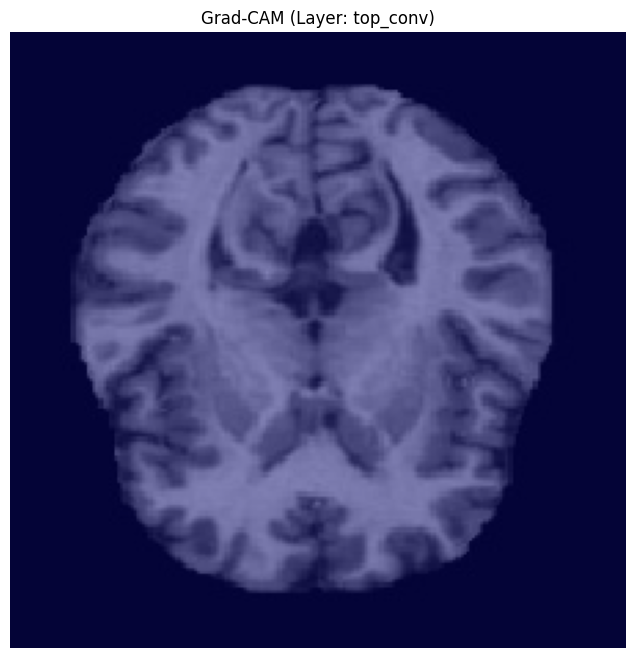

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

# 1. Get a sample image
img_batch, label_batch = next(val_gen)
img = img_batch[0]
img_input = np.expand_dims(img, axis=0)

# 2. Extract the base model and find the target layer
eff_base = eff_model.get_layer("efficientnetb0")
last_conv_layer_name = None
for layer in reversed(eff_base.layers):
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
        last_conv_layer_name = layer.name
        break

# 3. Create a model for the base only to avoid graph fragmentation
grad_model = tf.keras.models.Model(
    inputs=eff_base.input,
    outputs=[eff_base.get_layer(last_conv_layer_name).output, eff_base.output]
)

# 4. Compute Gradients
# We reconstruct the 'top' of the model inside the tape to keep the graph unified
with tf.GradientTape() as tape:
    conv_outputs, base_predictions = grad_model(img_input, training=False)

    # Re-apply top layers of eff_model manually
    x = eff_model.get_layer("global_average_pooling2d_3")(base_predictions)
    x = eff_model.get_layer("dense_8")(x)
    x = eff_model.get_layer("dropout_4")(x, training=False)
    predictions = eff_model.get_layer("dense_9")(x)

    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# 5. Generate Heatmap
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-10)
# Removed .numpy() as it's already a numpy array due to arithmetic with np.max
heatmap_np = heatmap

# 6. Superimpose and Display
heatmap_resized = cv2.resize(heatmap_np.numpy() if hasattr(heatmap_np, 'numpy') else heatmap_np, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

superimposed_img = heatmap_color * 0.4 + img * 0.6

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM (Layer: {last_conv_layer_name})")
plt.axis('off')
plt.show()

In [70]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

def get_predictions(model, generator):
    y_true = generator.classes
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    return y_true, y_pred, y_pred_probs

results = []

for name, model in models.items():
    print(f"Evaluating {name}...")
    y_true, y_pred, _ = get_predictions(model, val_gen)

    report = classification_report(y_true, y_pred, output_dict=True)

    results.append([
        name,
        report["accuracy"],
        report["weighted avg"]["precision"],
        report["weighted avg"]["recall"],
        report["weighted avg"]["f1-score"]
    ])

df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

df_results

Evaluating CNN...
Evaluating VGG16...
Evaluating MobileNetV2...
Evaluating EfficientNetB0...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-score
0,CNN,0.257603,0.257187,0.257603,0.255807
1,VGG16,0.256425,0.254064,0.256425,0.252904
2,MobileNetV2,0.253090,0.253910,0.253090,0.253186
3,EfficientNetB0,0.282519,0.079817,0.282519,0.124469


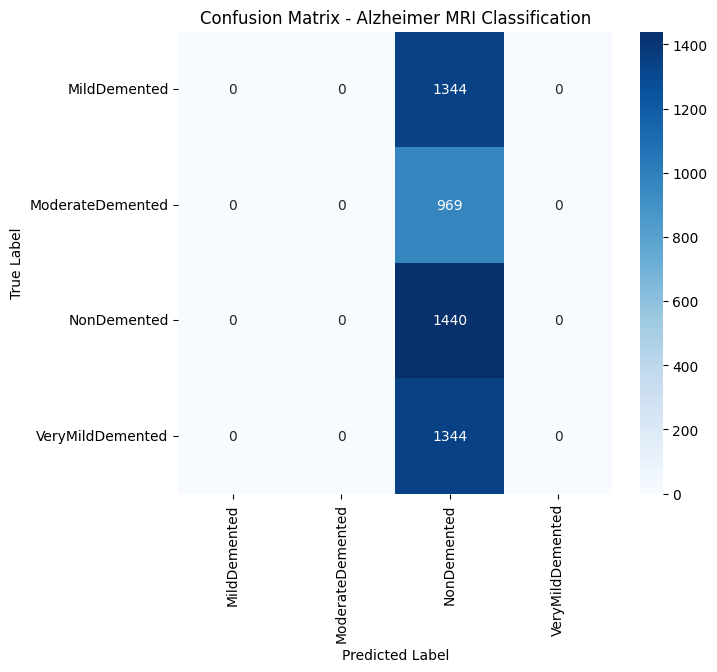

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# CHANGE MODEL HERE
# =========================
model = eff_model   # or cnn_model / vgg_model / mob_model

# =========================
# GET PREDICTIONS
# =========================
val_gen.reset()

y_prob = model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes

class_names = list(val_gen.class_indices.keys())

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Alzheimer MRI Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Spotting the disease

Using layer: top_activation


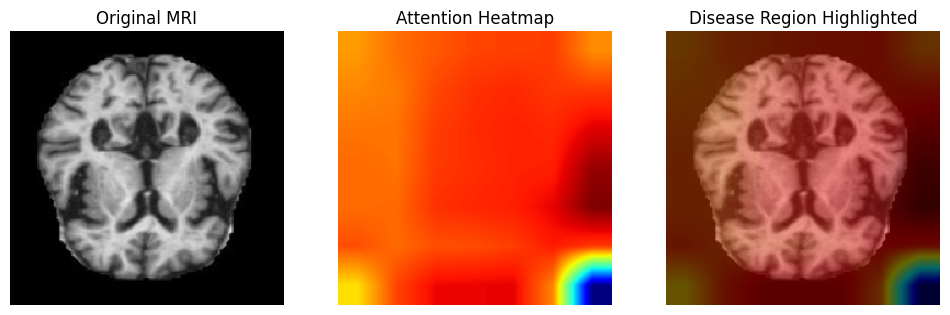

Predicted Class: NonDemented


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import cv2

# =========================
# STEP 1: PICK MODEL
# =========================
model = eff_model   # change if needed

# =========================
# STEP 2: GET ONE IMAGE
# =========================
img_batch, label_batch = next(val_gen)

img = img_batch[0]
img_input = np.expand_dims(img, axis=0)

# =========================
# STEP 3: FIND LAST CONV LAYER (AUTO SAFE)
# =========================
# Look inside the nested efficientnetb0 model for the last 4D conv layer
eff_base = model.get_layer("efficientnetb0")
last_conv_layer_name = None
for layer in reversed(eff_base.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name
        break

print("Using layer:", last_conv_layer_name)

# =========================
# STEP 4: GRAD-CAM MODEL
# =========================
# We build a model that goes from the base input to the target conv layer and final prediction
grad_model = tf.keras.models.Model(
    inputs=eff_base.input,
    outputs=[eff_base.get_layer(last_conv_layer_name).output, eff_base.output]
)

# =========================
# STEP 5: COMPUTE GRADIENTS
# =========================
with tf.GradientTape() as tape:
    conv_outputs, base_preds = grad_model(img_input, training=False)

    # Manually pass through the top layers to keep gradients connected
    x = model.get_layer("global_average_pooling2d_3")(base_preds)
    x = model.get_layer("dense_8")(x)
    x = model.get_layer("dropout_4")(x, training=False)
    predictions = model.get_layer("dense_9")(x)

    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-10)
heatmap_np = heatmap.numpy() if hasattr(heatmap, 'numpy') else heatmap

# =========================
# STEP 6: RESIZE HEATMAP
# =========================
heatmap_resized = cv2.resize(heatmap_np, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# =========================
# STEP 7: OVERLAY ON MRI
# =========================
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = cv2.addWeighted(
    (img * 255).astype("uint8"),
    0.6,
    heatmap_color,
    0.4,
    0
)

# =========================
# STEP 8: DISPLAY RESULTS
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Attention Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Disease Region Highlighted")
plt.axis("off")

plt.show()

# =========================
# STEP 9: SHOW PREDICTION
# =========================
pred_class = np.argmax(predictions[0])
print("Predicted Class:", list(val_gen.class_indices.keys())[pred_class])

CLASS-WISE GRAD-CAM VISUALIZATION

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

model = eff_model  # Using your existing EfficientNetB0 model
class_names = list(val_gen.class_indices.keys())

def get_last_conv_layer(model):
    # Extract the base model since the conv layers are nested
    base_model = model.get_layer("efficientnetb0")
    for layer in reversed(base_model.layers):
        # Use .output.shape instead of .output_shape for Keras 3 compatibility
        if len(layer.output.shape) == 4:
            return layer.name
    return None

last_conv_name = get_last_conv_layer(model)
eff_base = model.get_layer("efficientnetb0")
print("Using layer:", last_conv_name)

# Create the Grad-CAM model targeting the base model's internal layer
grad_model = tf.keras.models.Model(
    inputs=eff_base.input,
    outputs=[eff_base.get_layer(last_conv_name).output, eff_base.output]
)

def gradcam(img_array):
    img_input = np.expand_dims(img_array, axis=0)

    with tf.GradientTape() as tape:
        conv_out, base_preds = grad_model(img_input)

        # Manually apply the top layers of your model to maintain the gradient path
        x = model.get_layer("global_average_pooling2d_3")(base_preds)
        x = model.get_layer("dense_8")(x)
        x = model.get_layer("dropout_4")(x, training=False)
        preds = model.get_layer("dense_9")(x)

        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-10)

    return heatmap.numpy() if hasattr(heatmap, 'numpy') else heatmap, preds[0]

Using layer: top_activation


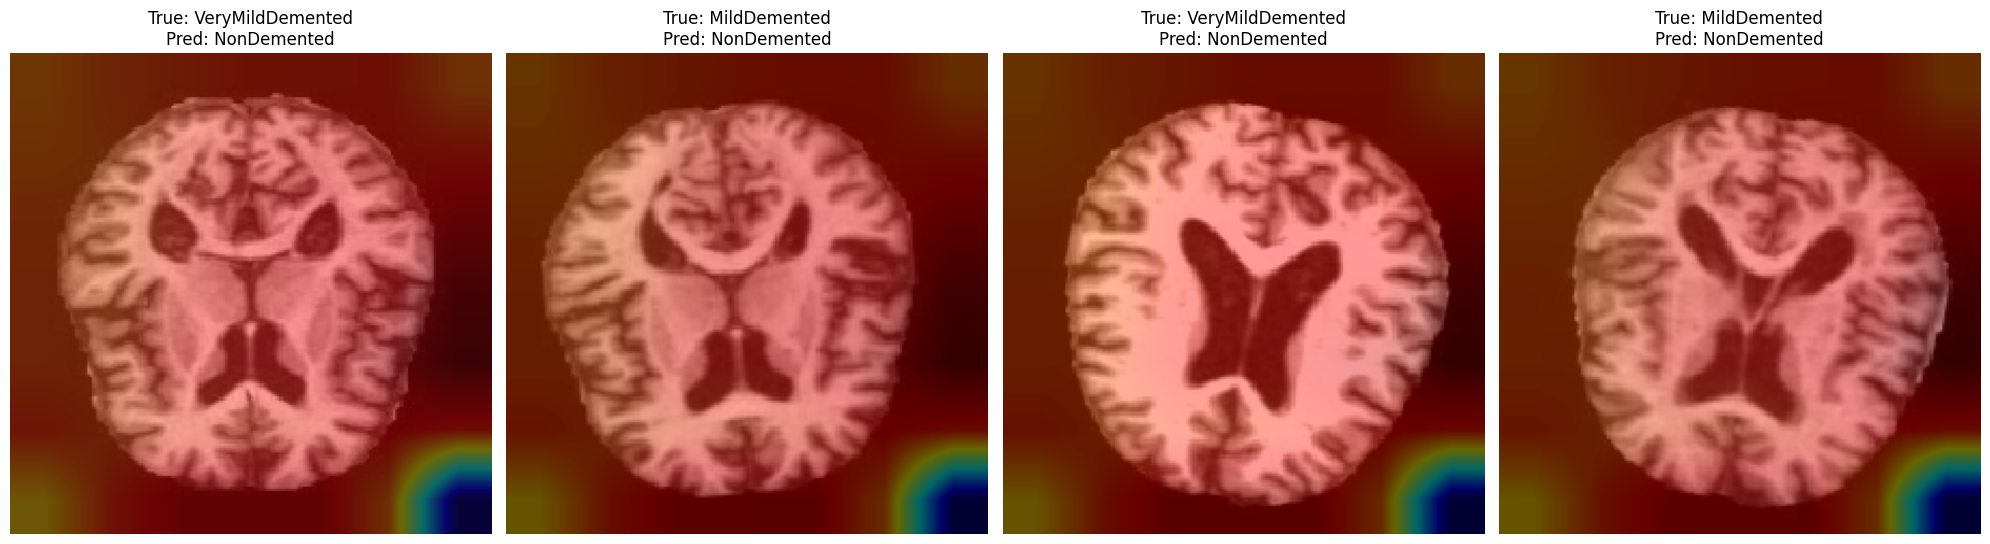

In [76]:
plt.figure(figsize=(20, 10))

# Reset generator to ensure we get a clean batch
val_gen.reset()
img_batch, label_batch = next(val_gen)

for i in range(4):
    img = img_batch[i]
    true_idx = np.argmax(label_batch[i])

    heatmap, preds = gradcam(img)
    pred_idx = np.argmax(preds)

    # Process heatmap
    heatmap_res = cv2.resize(heatmap, (224, 224))
    heatmap_res = np.uint8(255 * heatmap_res)
    heatmap_color = cv2.applyColorMap(heatmap_res, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Create overlay
    overlay = cv2.addWeighted((img * 255).astype('uint8'), 0.6, heatmap_color, 0.4, 0)

    plt.subplot(1, 4, i+1)
    plt.imshow(overlay)
    plt.title(f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

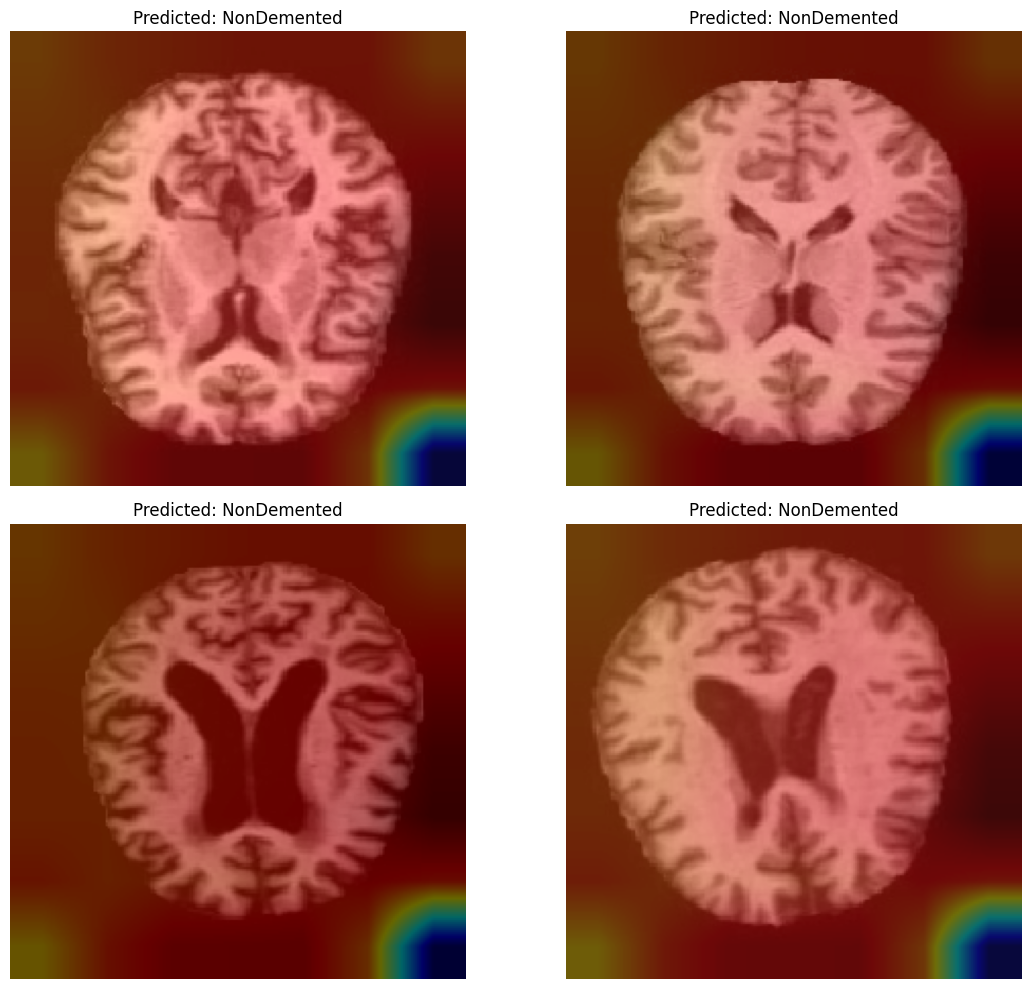

In [77]:
plt.figure(figsize=(12,10))

for i in range(len(class_names)):

    # get image from batch
    img_batch, label_batch = next(val_gen)

    img = img_batch[i % len(img_batch)]

    heatmap, preds = gradcam(img)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        (img * 255).astype("uint8"),
        0.6,
        heatmap_color,
        0.4,
        0
    )

    pred_class = class_names[np.argmax(preds)]

    plt.subplot(2,2,i+1)
    plt.imshow(overlay)
    plt.title(f"Predicted: {pred_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

AI diagnosis report

In [78]:
def explain_prediction(img):

    heatmap, preds = gradcam(img)

    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    report = f"""
🧠 AI DIAGNOSIS REPORT
-----------------------
Prediction: {pred_class}
Confidence: {confidence:.2f}

🔍 Interpretation:
The model focuses on brain regions showing structural changes
consistent with {pred_class.lower()} stage patterns.

⚠️ Note:
This is a supportive AI tool, not a clinical diagnosis.
"""
    print(report)

In [79]:
img_batch, _ = next(val_gen)
img = img_batch[0]

explain_prediction(img)


🧠 AI DIAGNOSIS REPORT
-----------------------
Prediction: NonDemented
Confidence: 0.28

🔍 Interpretation:
The model focuses on brain regions showing structural changes
consistent with nondemented stage patterns.

⚠️ Note:
This is a supportive AI tool, not a clinical diagnosis.



Model Comparison on visual explainability

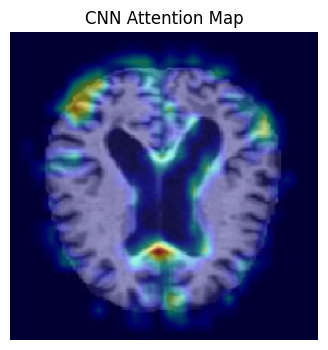

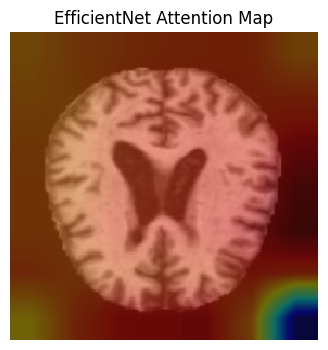

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

# Ensure model name compatibility
models = {
    "CNN": cnn_model,
    "EfficientNet": eff_model
}

def get_grad_model_robust(model):
    # Handle EfficientNet (Nested Base)
    if "efficientnetb0" in [l.name for l in model.layers]:
        base = model.get_layer("efficientnetb0")
        target_layer = next(l for l in reversed(base.layers) if len(l.output.shape) == 4)
        # Create a sub-model for the base
        sub_model = tf.keras.models.Model(inputs=base.input, outputs=[target_layer.output, base.output])
        return sub_model, True
    else:
        # Handle Sequential CNN
        # Reconstruct as a functional model to ensure input/output nodes exist
        input_tensor = tf.keras.Input(shape=(224, 224, 3))
        x = input_tensor
        target_output = None
        target_layer_idx = 0

        # Find the last 4D layer index
        for i, layer in enumerate(model.layers):
             if len(layer.output.shape) == 4:
                 target_layer_idx = i

        # Build a temporary functional graph using the Sequential layers
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == target_layer_idx:
                target_output = x

        sub_model = tf.keras.models.Model(inputs=input_tensor, outputs=[target_output, x])
        return sub_model, False

for name, model in models.items():
    try:
        grad_tool, is_nested = get_grad_model_robust(model)

        img_batch, _ = next(val_gen)
        img = img_batch[0]
        img_input = np.expand_dims(img, axis=0)

        with tf.GradientTape() as tape:
            conv_out, base_or_full_preds = grad_tool(img_input)

            if is_nested:
                # Re-run EfficientNet top layers
                x = model.get_layer("global_average_pooling2d_3")(base_or_full_preds)
                x = model.get_layer("dense_8")(x)
                x = model.get_layer("dropout_4")(x, training=False)
                preds = model.get_layer("dense_9")(x)
            else:
                preds = base_or_full_preds

            loss = preds[:, tf.argmax(preds[0])]

        grads = tape.gradient(loss, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

        heatmap = conv_out[0] @ pooled[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap).numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-10)
        heatmap = cv2.resize(heatmap, (224, 224))

        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.imshow(heatmap, cmap='jet', alpha=0.4)
        plt.title(f"{name} Attention Map")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Could not process {name}: {e}")

Building Medical Diagnosis Dashboard

In [86]:
!pip install streamlit pyngrok tensorflow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.9 MB/s eta 0:00:00


In [87]:
eff_model.save("alzheimers_model.h5")

Streamlit APP code

In [88]:
%%writefile app.py

import streamlit as st
import numpy as np
import tensorflow as tf
import cv2
from PIL import Image

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model("alzheimers_model.h5")

class_names = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']

# =========================
# GRAD-CAM FUNCTION
# =========================
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if len(layer.output_shape) == 4:
            return layer.name
    return None

last_conv = get_last_conv_layer(model)

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv).output, model.output]
)

def gradcam(img_array):
    img_input = np.expand_dims(img_array, axis=0)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_input)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap.numpy(), preds[0]

# =========================
# UI
# =========================
st.title("🧠 Alzheimer MRI Diagnosis AI")

uploaded_file = st.file_uploader("Upload MRI Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    img = Image.open(uploaded_file).convert('RGB')
    img = img.resize((224,224))
    img_array = np.array(img)/255.0

    st.image(img, caption="Uploaded MRI", use_column_width=True)

    heatmap, preds = gradcam(img_array)

    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    st.subheader("🧠 Prediction")
    st.write(f"**Class:** {pred_class}")
    st.write(f"**Confidence:** {confidence:.2f}")

    # =========================
    # HEATMAP
    # =========================
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        (img_array*255).astype("uint8"),
        0.6,
        heatmap_color,
        0.4,
        0
    )

    st.subheader("🔥 Attention Map (Grad-CAM)")
    st.image(overlay, use_column_width=True)

    # =========================
    # REPORT
    # =========================
    st.subheader("📄 AI Explanation Report")

    st.write(f"""
    Prediction: {pred_class}

    The model highlights brain regions associated with structural changes
    consistent with {pred_class.lower()} stage.

    ⚠️ This is an AI-assisted tool and not a clinical diagnosis.
    """)

Writing app.py


In [92]:
from pyngrok import ngrok

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.185.6:8501

